In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import networkx as nx
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

sys.path.insert(1, '../utils')
from sklearn.feature_selection import mutual_info_regression as MI

from utils import * 
from plotUtils import *
from fcMeasure import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
def sort_filesK(files_dict):
    # sorting based on K value
    _sortresults = {}

    for var, files in files_dict.items():
        _sortresults[var] = []
        Karr = []

        for _file in files:
            basename = os.path.basename(_file).split('.pkl')[0]
            K = float(basename.split('_')[3])
            Karr.append(K)

            _sortresults[var].append(_file)

        Karr = np.array(Karr)
        _sortresults[var] = np.array(_sortresults[var])
    
        Ksort = np.argsort(Karr)

        _sortresults[var] = _sortresults[var][Ksort]
    return _sortresults, Karr[Ksort]

def _sort_filesK(files):
    # sorting based on K value

    Karr_cv = []
    Karr_lyap = []

    _resultsLyap = []
    _resultsCV = []

    for _file in files:
        basename = os.path.basename(_file).split('.pkl')[0]
        _type = basename.split('_')[-1]
        K = float(basename.split('_')[-2])

        if _type == 'cv':
            Karr_cv.append(K)
            _resultsCV.append(_file)
        
        elif _type == 'lyap':
            Karr_lyap.append(K)
            _resultsLyap.append(_file)

    Karr_cv = np.array(Karr_cv)
    Karr_lyap = np.array(Karr_lyap)

    _resultsLyap = np.array(_resultsLyap)
    _resultsCV = np.array(_resultsCV)

    Ksort_cv = np.argsort(Karr_cv)
    Ksort_lyap = np.argsort(Karr_lyap)

    _resultsLyap = _resultsLyap[Ksort_lyap]
    _resultsCV = _resultsCV[Ksort_cv]

    return _resultsLyap, _resultsCV, Karr_lyap[Ksort_lyap]

In [3]:
def _lyapunov_plot_arr(_filesLyap, Xvals, sige = [0, 2], sigi = [1, -1]):
    modLyap_mean = np.zeros((4, len(Xvals)))
    modLyap_var = np.zeros((4, len(Xvals)))
    Nbar = 9

    nonmodLyap_mean = np.zeros((Nbar, 4, len(Xvals)))
    nonmodLyap_var = np.zeros((Nbar, 4, len(Xvals)))

    for nf, _file in enumerate(_filesLyap):
        _lyapDict = pickle.load(open(_file, "rb"))

        modLyap_mean[0, nf] = _lyapDict["mod_node"][sige[0], sigi[0]]
        modLyap_mean[1, nf] = _lyapDict["mod_node"][sige[0], sigi[-1]]
        modLyap_mean[2, nf] = _lyapDict["mod_node"][sige[-1], sigi[0]]
        modLyap_mean[3, nf] = _lyapDict["mod_node"][sige[-1], sigi[-1]]

        modLyap_var[0, nf] = _lyapDict["mod_node_var"][sige[0], sigi[0]]
        modLyap_var[1, nf] = _lyapDict["mod_node_var"][sige[0], sigi[-1]]
        modLyap_var[2, nf] = _lyapDict["mod_node_var"][sige[-1], sigi[0]]
        modLyap_var[3, nf] = _lyapDict["mod_node_var"][sige[-1], sigi[-1]]

        nonmodLyap_mean[:, 0, nf] = _lyapDict["nonmod_nodes"][:, sige[0], sigi[0]]
        nonmodLyap_mean[:, 1, nf] = _lyapDict["nonmod_nodes"][:, sige[0], sigi[-1]]
        nonmodLyap_mean[:, 2, nf] = _lyapDict["nonmod_nodes"][:, sige[-1], sigi[0]]
        nonmodLyap_mean[:, 3, nf] = _lyapDict["nonmod_nodes"][:, sige[-1], sigi[-1]]

        nonmodLyap_var[:, 0, nf] = _lyapDict["nonmod_nodes_var"][:, sige[0], sigi[0]]
        nonmodLyap_var[:, 1, nf] = _lyapDict["nonmod_nodes_var"][:, sige[0], sigi[-1]]
        nonmodLyap_var[:, 2, nf] = _lyapDict["nonmod_nodes_var"][:, sige[-1], sigi[0]]
        nonmodLyap_var[:, 3, nf] = _lyapDict["nonmod_nodes_var"][:, sige[-1], sigi[-1]]

    
    subINF_mod = -10 if len(modLyap_mean[~np.isinf(abs(modLyap_mean))].flatten()) == 0 else min(-10, min(modLyap_mean[~np.isinf(abs(modLyap_mean))]))
    subINF_nonmod = -10 if len(nonmodLyap_mean[~np.isinf(abs(nonmodLyap_mean))].flatten()) == 0 else min(-10, min(nonmodLyap_mean[~np.isinf(abs(nonmodLyap_mean))]))

    modLyap_mean[np.isinf(abs(modLyap_mean))] = subINF_mod
    modLyap_var[np.isnan(modLyap_var)] = 0.0

    for n in range(Nbar):
        nodeMat = nonmodLyap_mean[n, :, :]
        nodeMatv = nonmodLyap_var[n, :, :]
        subINF_nonmod = -10 if len(nodeMat[~np.isinf(abs(nodeMat))].flatten()) == 0 else min(-10, min(nodeMat[~np.isinf(abs(nodeMat))]))

        nodeMat[np.isinf(abs(nodeMat))] = subINF_nonmod
        nodeMatv[np.isnan(abs(nodeMatv))] = 0.0

        nonmodLyap_mean[n, :, :] = nodeMat
        nonmodLyap_var[n, :, :] = nodeMatv

    return modLyap_mean, modLyap_var, nonmodLyap_mean, nonmodLyap_var

In [4]:
def lyapunov_plot_arr(_filesLyap, Xvals, sige = [0, 2], sigi = [1, -1]):
    modLyapMean = {}
    modLyapVar = {}
    Nbar = 9

    nmodLyapMean = {}
    nmodLyapVar = {}

    for var, files in _filesLyap.items():
        modLyapMean[var] =  np.zeros((4, len(Xvals)))
        modLyapVar[var] =  np.zeros((4, len(Xvals)))

        nmodLyapMean[var] = np.zeros((Nbar, 4, len(Xvals)))
        nmodLyapVar[var] = np.zeros((Nbar, 4, len(Xvals)))

        for nf, _file in enumerate(files):
            _lyapDict = pickle.load(open(_file, "rb"))['Lyapunov']

            modLyapMean[var][0, nf] = _lyapDict["mod_node"][sige[0], sigi[0]]
            modLyapMean[var][1, nf] = _lyapDict["mod_node"][sige[0], sigi[-1]]
            modLyapMean[var][2, nf] = _lyapDict["mod_node"][sige[-1], sigi[0]]
            modLyapMean[var][3, nf] = _lyapDict["mod_node"][sige[-1], sigi[-1]]

            modLyapVar[var][0, nf] = _lyapDict["mod_node_var"][sige[0], sigi[0]]
            modLyapVar[var][1, nf] = _lyapDict["mod_node_var"][sige[0], sigi[-1]]
            modLyapVar[var][2, nf] = _lyapDict["mod_node_var"][sige[-1], sigi[0]]
            modLyapVar[var][3, nf] = _lyapDict["mod_node_var"][sige[-1], sigi[-1]]

            nmodLyapMean[var][:, 0, nf] = _lyapDict["nonmod_nodes"][:, sige[0], sigi[0]]
            nmodLyapMean[var][:, 1, nf] = _lyapDict["nonmod_nodes"][:, sige[0], sigi[-1]]
            nmodLyapMean[var][:, 2, nf] = _lyapDict["nonmod_nodes"][:, sige[-1], sigi[0]]
            nmodLyapMean[var][:, 3, nf] = _lyapDict["nonmod_nodes"][:, sige[-1], sigi[-1]]

            nmodLyapVar[var][:, 0, nf] = _lyapDict["nonmod_nodes_var"][:, sige[0], sigi[0]]
            nmodLyapVar[var][:, 1, nf] = _lyapDict["nonmod_nodes_var"][:, sige[0], sigi[-1]]
            nmodLyapVar[var][:, 2, nf] = _lyapDict["nonmod_nodes_var"][:, sige[-1], sigi[0]]
            nmodLyapVar[var][:, 3, nf] = _lyapDict["nonmod_nodes_var"][:, sige[-1], sigi[-1]]

        subINF_mod = -10 if len(modLyapMean[var][~np.isinf(abs(modLyapMean[var]))].flatten()) == 0 else min(-10, min(modLyapMean[var][~np.isinf(abs(modLyapMean[var]))]))
        subINF_nonmod = -10 if len(nmodLyapMean[var][~np.isinf(abs(nmodLyapMean[var]))].flatten()) == 0 else min(-10, min(nmodLyapMean[var][~np.isinf(abs(nmodLyapMean[var]))]))
    
        modLyapMean[var][np.isinf(abs(modLyapMean[var]))] = subINF_mod
        modLyapVar[var][np.isnan(modLyapVar[var])] = 0.0    

        for n in range(Nbar):
            nodeMat = nmodLyapMean[var][n, :, :]
            nodeMatv = nmodLyapVar[var][n, :, :]
            subINF_nonmod = -10 if len(nodeMat[~np.isinf(abs(nodeMat))].flatten()) == 0 else min(-10, min(nodeMat[~np.isinf(abs(nodeMat))]))

            nodeMat[np.isinf(abs(nodeMat))] = subINF_nonmod
            nodeMatv[np.isnan(abs(nodeMatv))] = 0.0

            nmodLyapMean[var][n, :, :] = nodeMat
            nmodLyapVar[var][n, :, :] = nodeMatv

    return modLyapMean, modLyapVar, nmodLyapMean, nmodLyapVar

In [5]:
def _cv_plot_arr(_filesCV, Xvals, sige = [0, 2], sigi = [1, -1]):
    cvMean = np.zeros((4, len(Xvals)))
    cvVar = np.zeros((4, len(Xvals)))
    N = 10
    MeanMean = np.zeros((N, 4, len(Xvals)))
    MeanVar = np.zeros((N, 4, len(Xvals)))
    VarMean = np.zeros((N, 4, len(Xvals)))
    VarVar = np.zeros((N, 4, len(Xvals)))

    for nf, _file in enumerate(_filesCV):
        _cv = pickle.load(open(_file, "rb"))
        _cvMean = abs(_cv["mean_cv"])
        _cvVar = _cv["var_cv"]

        cvMean[0, nf] = _cvMean[sige[0], sigi[0]]; cvVar[0, nf] = _cvVar[sige[0], sigi[0]]
        cvMean[1, nf] = _cvMean[sige[0], sigi[-1]]; cvVar[1, nf] = _cvVar[sige[0], sigi[-1]]
        cvMean[2, nf] = _cvMean[sige[-1], sigi[0]]; cvVar[2, nf] = _cvVar[sige[-1], sigi[0]]
        cvMean[3, nf] = _cvMean[sige[-1], sigi[-1]]; cvVar[3, nf] = _cvVar[sige[-1], sigi[-1]]

        MeanMean[:, 0, nf] = _cv["mean_mean"][:, sige[0], sigi[0]]
        MeanMean[:, 1, nf] = _cv["mean_mean"][:, sige[0], sigi[-1]]
        MeanMean[:, 2, nf] = _cv["mean_mean"][:, sige[-1], sigi[0]]
        MeanMean[:, 3, nf] = _cv["mean_mean"][:, sige[-1], sigi[-1]]

        VarMean[:, 0, nf] = _cv["var_mean"][:, sige[0], sigi[0]]
        VarMean[:, 1, nf] = _cv["var_mean"][:, sige[0], sigi[-1]]
        VarMean[:, 2, nf] = _cv["var_mean"][:, sige[-1], sigi[0]]
        VarMean[:, 3, nf] = _cv["var_mean"][:, sige[-1], sigi[-1]]

        MeanVar[:, 0, nf] = _cv["mean_var"][:, sige[0], sigi[0]]
        MeanVar[:, 1, nf] = _cv["mean_var"][:, sige[0], sigi[-1]]
        MeanVar[:, 2, nf] = _cv["mean_var"][:, sige[-1], sigi[0]]
        MeanVar[:, 3, nf] = _cv["mean_var"][:, sige[-1], sigi[-1]]

        VarVar[:, 0, nf] = _cv["var_var"][:, sige[0], sigi[0]]
        VarVar[:, 1, nf] = _cv["var_var"][:, sige[0], sigi[-1]]
        VarVar[:, 2, nf] = _cv["var_var"][:, sige[-1], sigi[0]]
        VarVar[:, 3, nf] = _cv["var_var"][:, sige[-1], sigi[-1]]
    
    return cvMean, cvVar, MeanMean, MeanVar, VarMean, VarVar

In [6]:
def cv_plot_arr(_filesCV, Xvals, sige = [0, 2], sigi = [1, -1]):
    N = 10

    CVMean = {} 
    CVVar = {} 
    
    MeanMean = {}
    MeanVar = {}
    VarMean = {}
    VarVar = {}

    for var, files in _filesCV.items():
        CVMean[var] =  np.zeros((4, len(Xvals)))
        CVVar[var] =  np.zeros((4, len(Xvals)))
    
        MeanMean[var] = np.zeros((N, 4, len(Xvals)))
        MeanVar[var] = np.zeros((N, 4, len(Xvals)))
        VarMean[var] = np.zeros((N, 4, len(Xvals)))
        VarVar[var] = np.zeros((N, 4, len(Xvals)))

        for nf, _file in enumerate(files):
            _cv = pickle.load(open(_file, "rb"))["CV"]
            _cvMean = abs(_cv["mean_cv"])
            _cvVar = _cv["var_cv"]

            CVMean[var][0, nf] = _cvMean[sige[0], sigi[0]]; CVVar[var][0, nf] = _cvVar[sige[0], sigi[0]]
            CVMean[var][1, nf] = _cvMean[sige[0], sigi[-1]]; CVVar[var][1, nf] = _cvVar[sige[0], sigi[-1]]
            CVMean[var][2, nf] = _cvMean[sige[-1], sigi[0]]; CVVar[var][2, nf] = _cvVar[sige[-1], sigi[0]]
            CVMean[var][3, nf] = _cvMean[sige[-1], sigi[-1]]; CVVar[var][3, nf] = _cvVar[sige[-1], sigi[-1]]
            
            MeanMean[var][:, 0, nf] = _cv["mean_mean"][:, sige[0], sigi[0]]
            MeanMean[var][:, 1, nf] = _cv["mean_mean"][:, sige[0], sigi[-1]]
            MeanMean[var][:, 2, nf] = _cv["mean_mean"][:, sige[-1], sigi[0]]
            MeanMean[var][:, 3, nf] = _cv["mean_mean"][:, sige[-1], sigi[-1]]

            VarMean[var][:, 0, nf] = _cv["var_mean"][:, sige[0], sigi[0]]
            VarMean[var][:, 1, nf] = _cv["var_mean"][:, sige[0], sigi[-1]]
            VarMean[var][:, 2, nf] = _cv["var_mean"][:, sige[-1], sigi[0]]
            VarMean[var][:, 3, nf] = _cv["var_mean"][:, sige[-1], sigi[-1]]

            MeanVar[var][:, 0, nf] = _cv["mean_var"][:, sige[0], sigi[0]]
            MeanVar[var][:, 1, nf] = _cv["mean_var"][:, sige[0], sigi[-1]]
            MeanVar[var][:, 2, nf] = _cv["mean_var"][:, sige[-1], sigi[0]]
            MeanVar[var][:, 3, nf] = _cv["mean_var"][:, sige[-1], sigi[-1]]

            VarVar[var][:, 0, nf] = _cv["var_var"][:, sige[0], sigi[0]]
            VarVar[var][:, 1, nf] = _cv["var_var"][:, sige[0], sigi[-1]]
            VarVar[var][:, 2, nf] = _cv["var_var"][:, sige[-1], sigi[0]]
            VarVar[var][:, 3, nf] = _cv["var_var"][:, sige[-1], sigi[-1]]
    
    return CVMean, CVVar, MeanMean, MeanVar, VarMean, VarVar

In [7]:
def meanvarplot(response_map, Xarr, M = 1, Ylabel=r"$K_\mathrm{glob}$", figsize=(6,4), offset=5, nNodes = 10, variable = r"$\mu_u$", figroot = None, filename=None):
    pSige = [2.5, 7.5]
    pSigi = [4.4, 16.5]
    _colors = ["Blues", "Greens", "Reds", "Purples"]
    colors = ["b", "g", "r", "purple"]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True, layout="constrained")
    if M == 0:
        response_map = response_map[::-1, :, :]
    nRow = 0; nCol = 0
    for k in range(4):
        pcol = axes[nRow,nCol].pcolormesh(Xarr, np.arange(nNodes), response_map[:, k, :], cmap=_colors[k], vmin=np.min(response_map), vmax = np.max(response_map))
        if max(Xarr) == 1:
            axes[nRow,nCol].add_patch(Rectangle((min(Xarr)-0.09, M-0.5), (max(Xarr) - min(Xarr))+0.18, 9, facecolor="none", ec='k', lw=3, ls=':'))
        else:
            axes[nRow,nCol].add_patch(Rectangle((min(Xarr)-4.5, M-0.5), (max(Xarr) - min(Xarr))+9, 9, facecolor="none", ec='k', lw=3, ls=':'))
        cbar = plt.colorbar(pcol, ax=axes[nRow,nCol], location='right', pad=0.05)
        if nCol != 1:
            cbar.ax.get_yaxis().set_ticks([])
        cbar.ax.text(0, np.max(response_map) + offset, variable, rotation=0, ha='center', va='center', fontsize=12)
        axes[nRow, nCol].text(-0.4, 10.5, r"$\mathbf{\sigma} = [$" + f"{pSige[nRow]}, {pSigi[nCol]}" + r"$]^T$", color=colors[k], fontsize=12)
        for pos in ["right", "top"]:
            axes[nRow,nCol].spines[pos].set_visible(False)


        if nCol == 0:
            axes[nRow,nCol].set_yticks(np.arange(1, 10, 2), np.arange(2, 11, 2))
        
        if nRow == 1:
            if len(Xarr) > 5:
                axes[nRow,nCol].set_xticks(Xarr[::3])
            else:
                axes[nRow,nCol].set_xticks(Xarr[0::2])
        nCol += 1
        if nCol == 2:
            nCol = 0
            nRow += 1

    fig.supylabel("# Node")
    fig.supxlabel(Ylabel)
    plt.savefig(os.path.join(figroot, filename), dpi=300, bbox_inches='tight')
    plt.show()
    return

In [8]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

nTrials = 10
nRealizations = 10

params["N"] = nNodes = 10
minval = -5 / params['gamma']
maxval = 5 / params['gamma']

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

t_start = 1000
t_end = T

figureroot = "./results/volatility"
os.makedirs(figureroot, exist_ok=True)

In [9]:
modAmp = np.array([0.5, 0.35, 0.25, 0.15, 0.0]) / params['gamma']
sigArr = np.array([2.5, 4.4, 7.5, 10.5, 13.5, 16.5])
sigVar = np.array([0.01, 0.1, 1, 2])

params['i_mod'] = modAmp[0]

In [10]:
rootRA = "Setup_A3"
volatileR_dir = "results/volatility"

saveR_str = datetime.datetime(2024, 5, 10)
subR_dir = f"exp-{saveR_str.year}-{saveR_str.month}-{saveR_str.day}"

loadRA = os.path.join("../", rootRA, volatileR_dir, subR_dir)

_resultsR = glob.glob(os.path.join(loadRA, f"Imod_{params['i_mod']:.3f}mV*"))
print(f"No. of files = {len(_resultsR)}")

LyapRA, CVRA, Karr = _sort_filesK(_resultsR)
modLyapRA_mean, modLyapRA_var, nonmodLyapRA_mean, nonmodLyapRA_var = _lyapunov_plot_arr(LyapRA, Karr)
cvRAMean, cvRAVar, MeanMeanRA, MeanVarRA, VarMeanRA, VarVarRA = _cv_plot_arr(CVRA, Karr)

No. of files = 22


In [11]:
rootA = "Setup_A3v"
volatile_dir = "results/volatility"

save_str = datetime.datetime(2024, 5, 10)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadA = os.path.join("../", rootA, volatile_dir, sub_dir)

figurerootA = "./results/volatility/ConfigureAv"
os.makedirs(figurerootA, exist_ok=True)

In [12]:
_resA = {}
for Var in sigVar:
    _results = glob.glob(os.path.join(loadA, f"Imod_{params['i_mod']:.3f}mV*_sigVar_{Var:.2f}*"))
    print(f"Sigma variance {Var:.2f} --> No. of files = {len(_results)}")
    _resA[Var] = np.array(_results)

Sigma variance 0.01 --> No. of files = 11
Sigma variance 0.10 --> No. of files = 11
Sigma variance 1.00 --> No. of files = 11
Sigma variance 2.00 --> No. of files = 11


In [13]:
SortA, Karr = sort_filesK(_resA)
modLyapA_mean, modLyapA_var, nonmodLyapA_mean, nonmodLyapA_var= lyapunov_plot_arr(SortA, Karr)
cvAMean, cvAVar, MeanMeanA, MeanVarA, VarMeanA, VarVarA= cv_plot_arr(SortA, Karr)

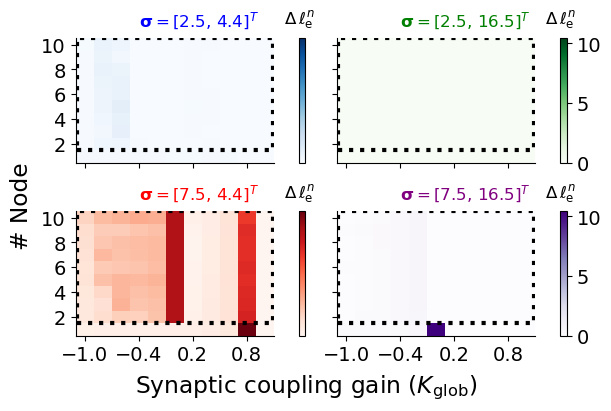

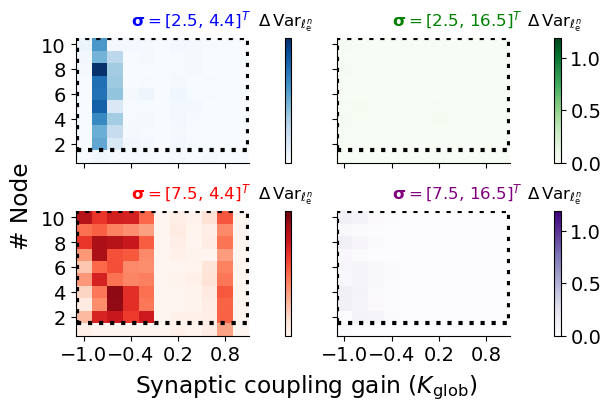

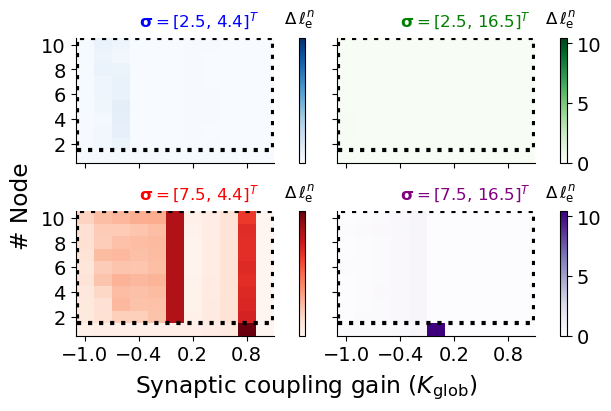

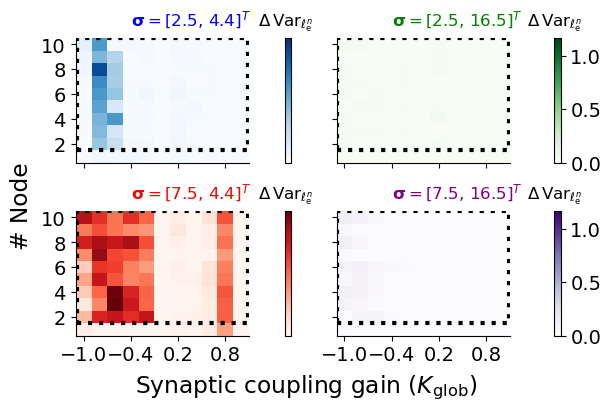

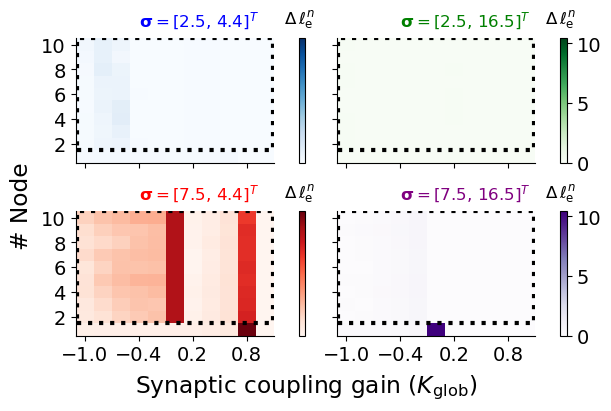

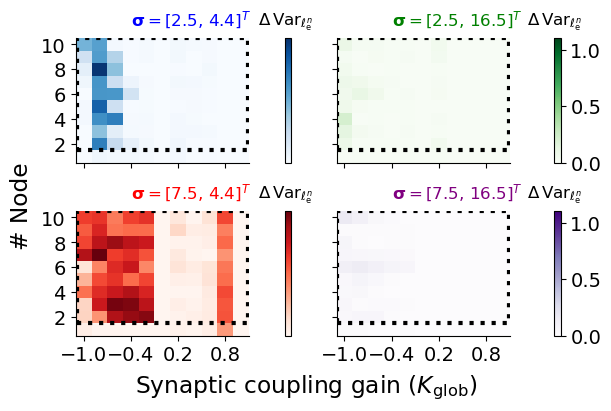

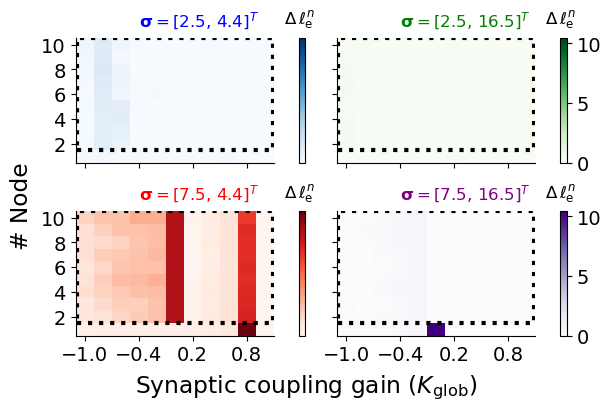

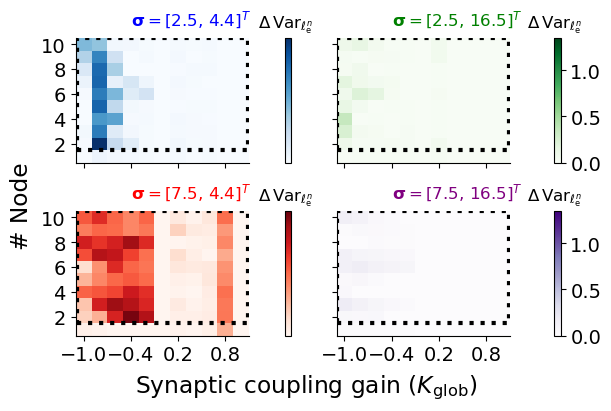

In [14]:
Ylabel=r"Synaptic coupling gain $(K_\mathrm{glob})$"

for var in modLyapA_mean.keys():
    fullLyapMeanA = np.zeros((nNodes, 4, len(Karr)))
    fullLyapVarA = np.zeros((nNodes, 4, len(Karr)))

    fullLyapMeanA[0, :, :] = abs(modLyapA_mean[var] - modLyapRA_mean)
    fullLyapMeanA[1:, :, :] = abs(nonmodLyapA_mean[var] - nonmodLyapRA_mean)

    fullLyapVarA[0, :, :] = abs(modLyapA_var[var] - modLyapRA_var)
    fullLyapVarA[1:, :, :] = abs(nonmodLyapA_var[var] - nonmodLyapRA_var)
    
    meanvarplot(fullLyapMeanA, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1.5, variable = r"$\Delta\,\ell_{\rm e}^n$",
                    figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_LyapMean.jpg")
    meanvarplot(fullLyapVarA, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=0.15, variable = r"$\Delta\,\mathrm{Var}_{\ell_{\rm e}^n}$",
                    figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_LyapVar.jpg")

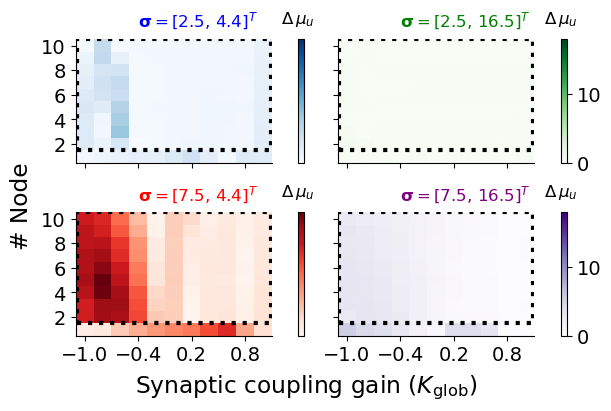

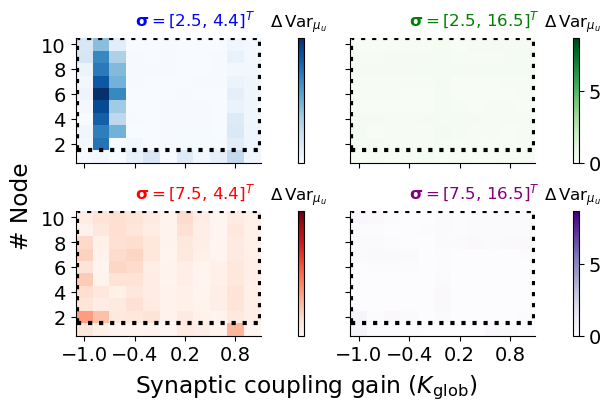

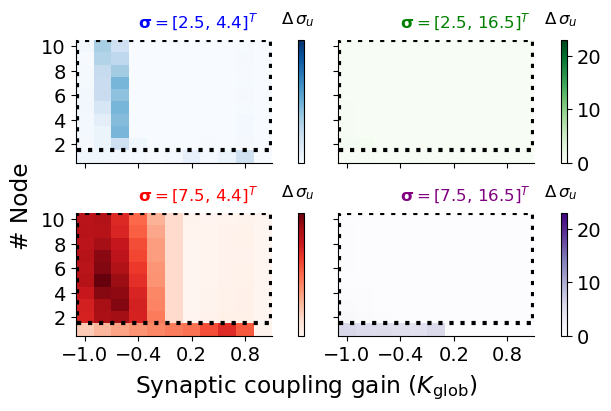

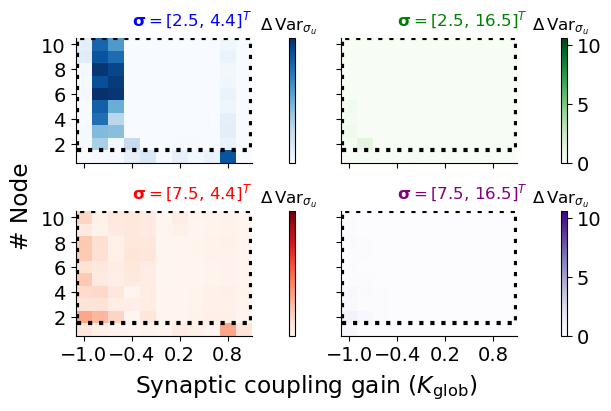

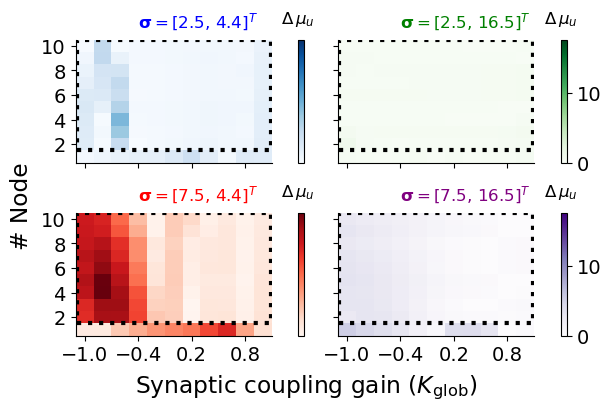

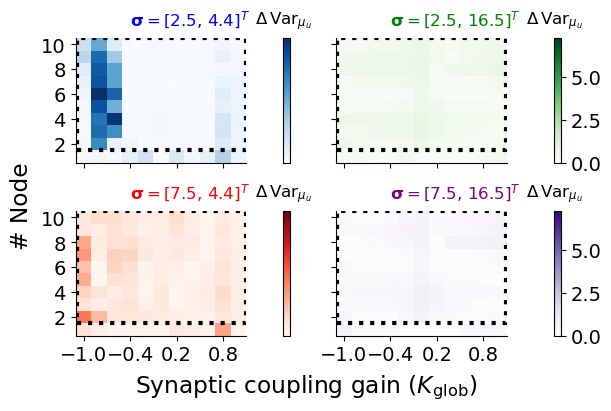

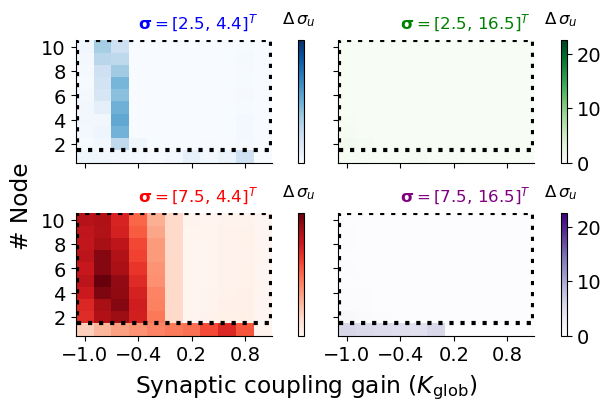

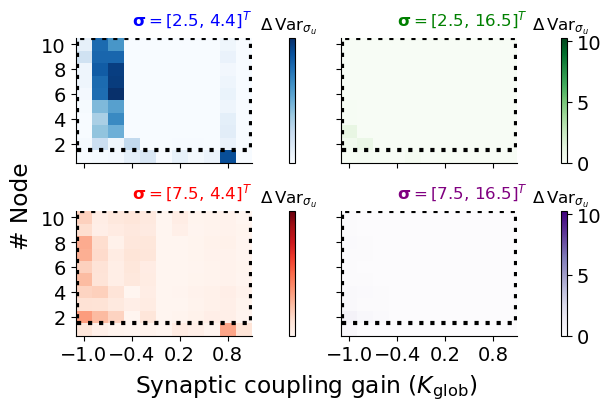

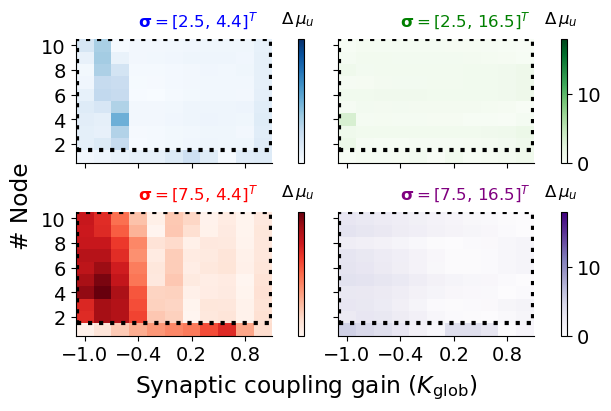

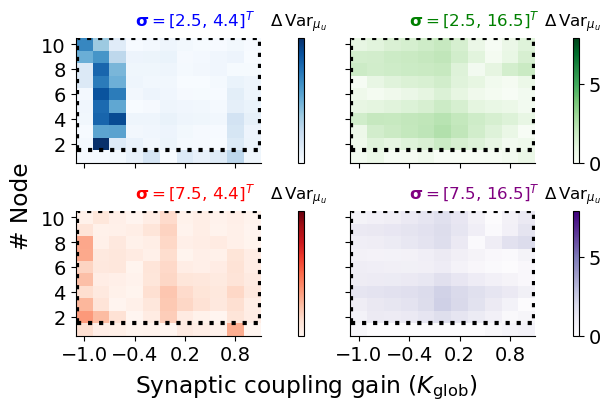

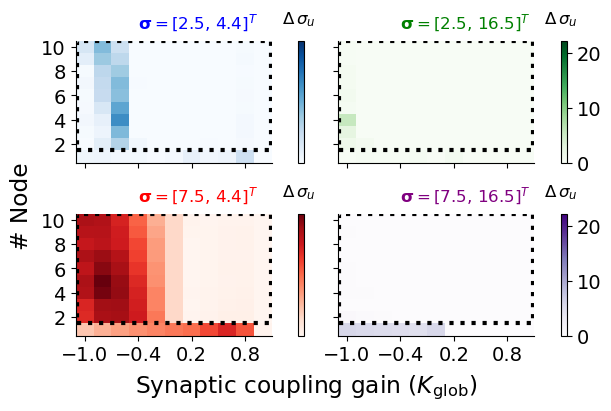

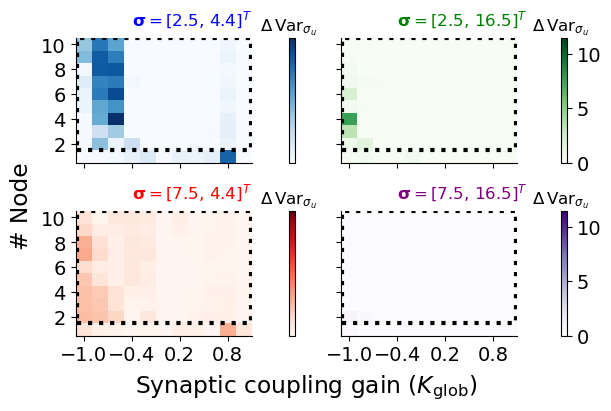

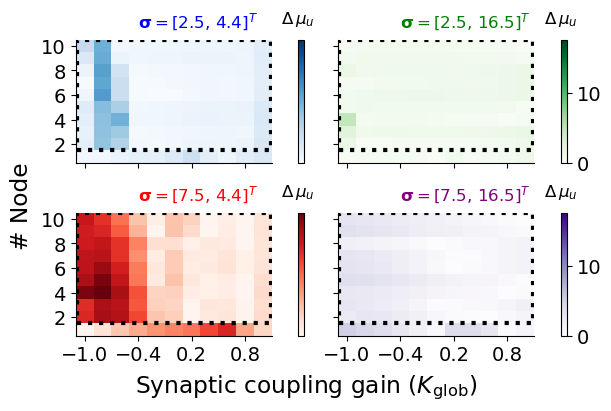

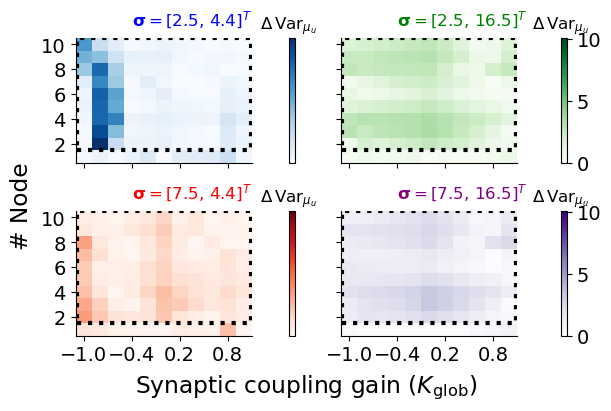

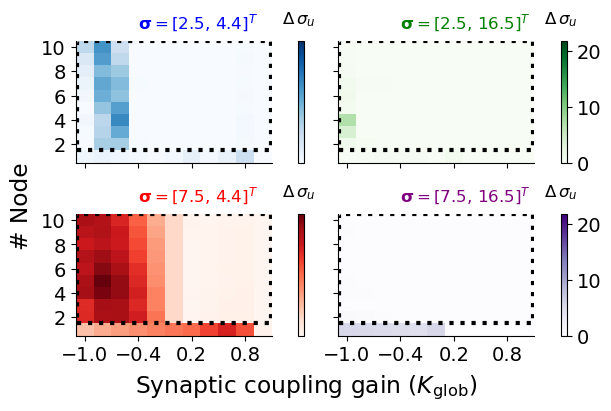

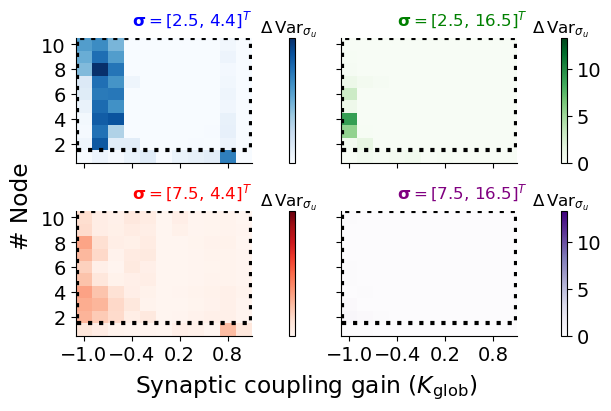

In [15]:
Ylabel=r"Synaptic coupling gain $(K_\mathrm{glob})$"

for var in modLyapA_mean.keys():
    fullLyapMeanA = np.zeros((nNodes, 4, len(Karr)))
    fullLyapVarA = np.zeros((nNodes, 4, len(Karr)))

    fullLyapMeanA[0, :, :] = abs(modLyapA_mean[var] - modLyapRA_mean)
    fullLyapMeanA[1:, :, :] = abs(nonmodLyapA_mean[var] - nonmodLyapRA_mean)

    fullLyapVarA[0, :, :] = abs(modLyapA_var[var] - modLyapRA_var)
    fullLyapVarA[1:, :, :] = abs(nonmodLyapA_var[var] - nonmodLyapRA_var)

    meanvarplot(abs(MeanMeanA[var] - MeanMeanRA), figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=3, variable = r"$\Delta\,\mu_u$",
                    figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_MeanNeural.jpg")
    meanvarplot(abs(VarMeanA[var] - VarMeanRA), figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1, variable = r"$\Delta\,\mathrm{Var}_{\mu_u}$",
                    figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_VarMeanNeural.jpg")
    meanvarplot(abs(MeanVarA[var] - MeanVarRA), figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=4, variable = r"$\Delta\,\sigma_u$",
                    figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_VarNeural.jpg")
    meanvarplot(abs(VarVarA[var] - VarVarRA), figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1, variable = r"$\Delta\,\mathrm{Var}_{\sigma_u}$",
                    figroot=figurerootA, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_VarVarNeural.jpg")

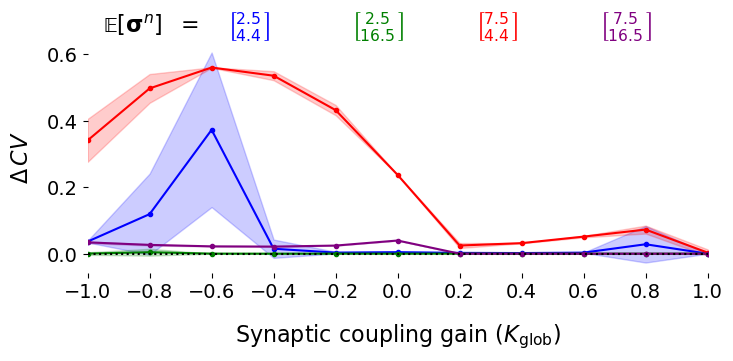

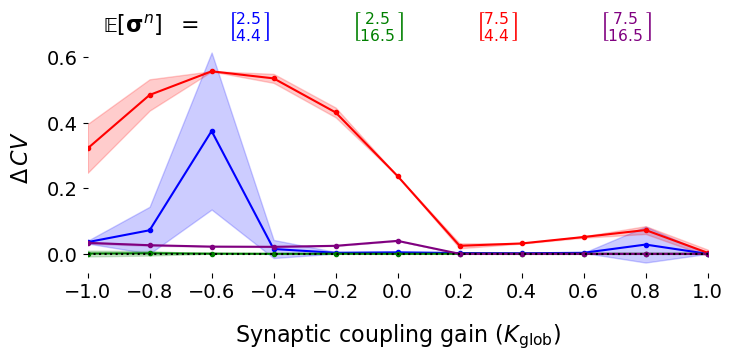

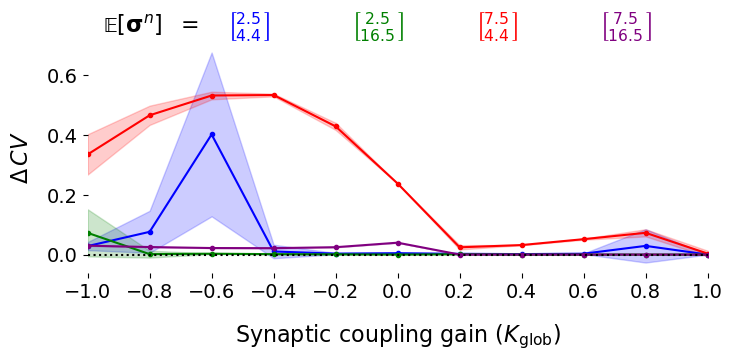

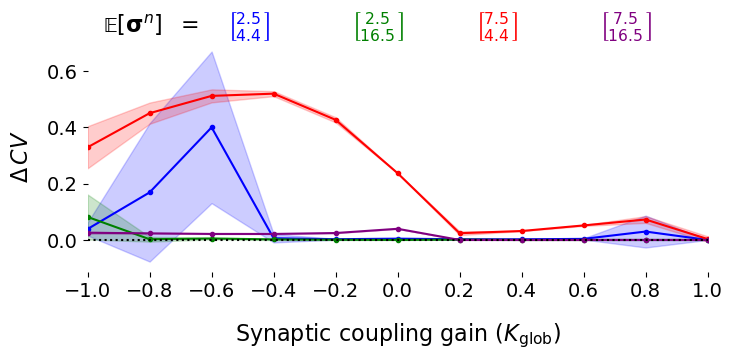

In [16]:
colors = ['b', 'g', 'r', 'purple']
for var in cvAMean.keys():
    plt.figure(figsize=(8, 3))
    dCVMean = abs(cvAMean[var] - cvRAMean)
    dCVVar = abs(cvAVar[var] - cvRAVar)

    for k in range(4):
        plt.plot(Karr, dCVMean[k, :], ".-", color=colors[k])
        plt.fill_between(Karr, dCVMean[k, :] - dCVVar[k, :], dCVMean[k, :] + dCVVar[k, :], color=colors[k], alpha=0.2)

    plt.axhline(y=0, color = 'k', linestyle=':')
    plt.ylabel(r"$\Delta\,CV$", fontsize=16, labelpad=10)
    plt.xlabel(r"Synaptic coupling gain $(K_{\mathrm{glob}})$", fontsize=16, labelpad=15)
    plt.xlim(min(Karr), max(Karr))
    plt.xticks(Karr)
    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)

    plt.text(-0.95, np.max(dCVMean + dCVVar) * 1.1 , r'$\mathrm{\mathbb{E}}[\mathbf{\sigma}^n]~~= $', color = 'k',  fontsize=16)

    plt.text(-0.55, np.max(dCVMean + dCVVar) * 1.1, r'$\genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
    plt.text(-0.15, np.max(dCVMean + dCVVar) * 1.1, r'$\genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
    plt.text(0.25, np.max(dCVMean + dCVVar) * 1.1, r'$\genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
    plt.text(0.65, np.max(dCVMean + dCVVar) * 1.1, r'$\genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

    plt.savefig(os.path.join(figurerootA, f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_dCV.jpg"), dpi=300, bbox_inches='tight')
    plt.show()

In [17]:
rootRB = "Setup_B3"
volatileR_dir = "results/volatility"

saveR_str = datetime.datetime(2024, 5, 10)
subR_dir = f"exp-{saveR_str.year}-{saveR_str.month}-{saveR_str.day}"

loadRB = os.path.join("../", rootRB, volatileR_dir, subR_dir)

_resultsR = glob.glob(os.path.join(loadRB, f"Imod_{params['i_mod']:.3f}mV*"))
print(f"No. of files = {len(_resultsR)}")

LyapRB, CVRB, Karr = _sort_filesK(_resultsR)
modLyapRB_mean, modLyapRB_var, nonmodLyapRB_mean, nonmodLyapRB_var = _lyapunov_plot_arr(LyapRB, Karr)
cvRBMean, cvRBVar, MeanMeanRB, MeanVarRB, VarMeanRB, VarVarRB = _cv_plot_arr(CVRB, Karr)

No. of files = 22


In [18]:
rootB = "Setup_B3v"
volatile_dir = "results/volatility"

save_str = datetime.datetime(2024, 5, 10)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadB = os.path.join("../", rootB, volatile_dir, sub_dir)

figurerootB = "./results/volatility/ConfigureBv"
os.makedirs(figurerootB, exist_ok=True)

In [19]:
_resB = {}
for Var in sigVar:
    _results = glob.glob(os.path.join(loadB, f"Imod_{params['i_mod']:.3f}mV*_sigVar_{Var:.2f}*"))
    print(f"Sigma variance {Var:.2f} --> No. of files = {len(_results)}")
    _resB[Var] = np.array(_results)

Sigma variance 0.01 --> No. of files = 11
Sigma variance 0.10 --> No. of files = 11
Sigma variance 1.00 --> No. of files = 11
Sigma variance 2.00 --> No. of files = 11


In [20]:
SortB, Karr = sort_filesK(_resB)
modLyapB_mean, modLyapB_var, nonmodLyapB_mean, nonmodLyapB_var= lyapunov_plot_arr(SortB, Karr)
cvBMean, cvBVar, MeanMeanB, MeanVarB, VarMeanB, VarVarB = cv_plot_arr(SortB, Karr)

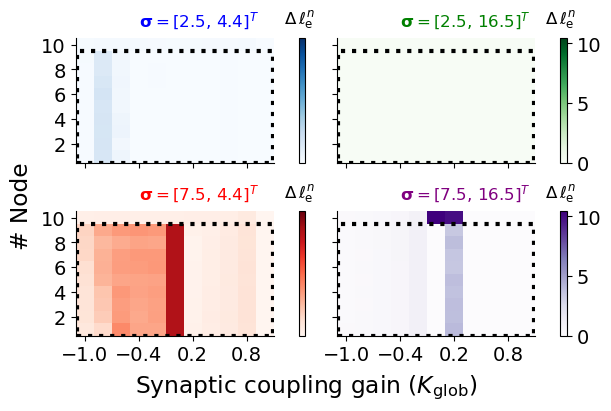

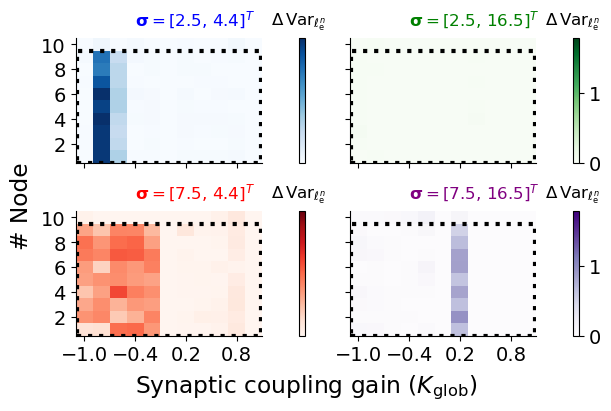

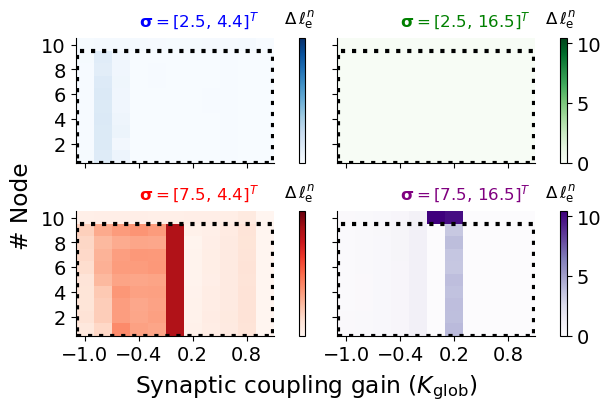

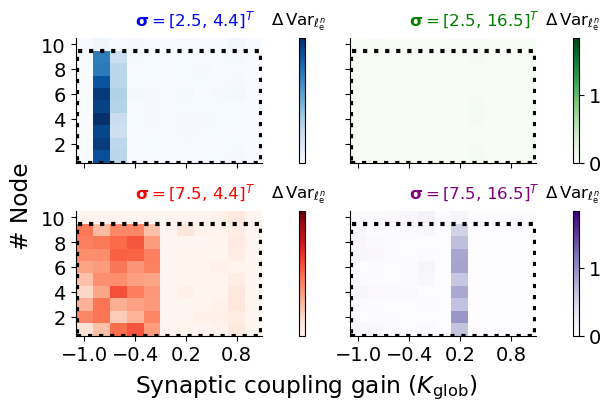

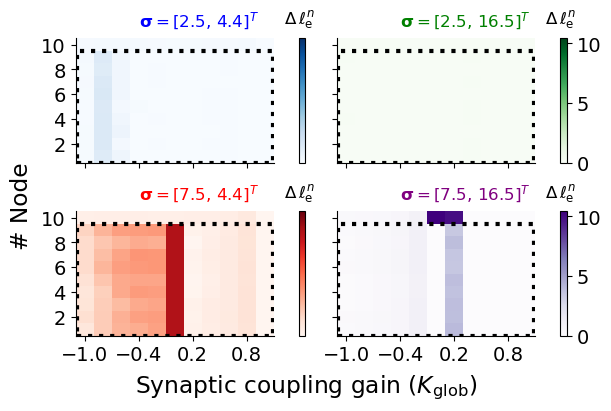

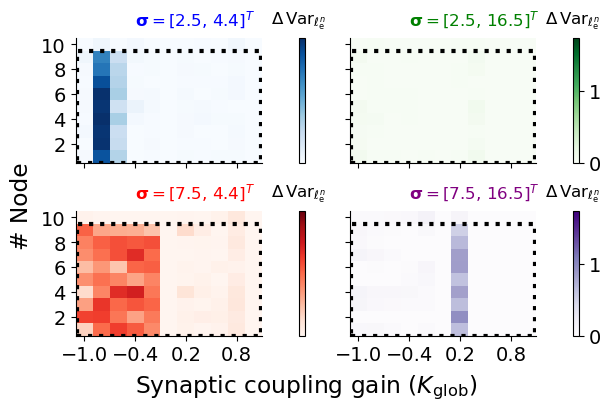

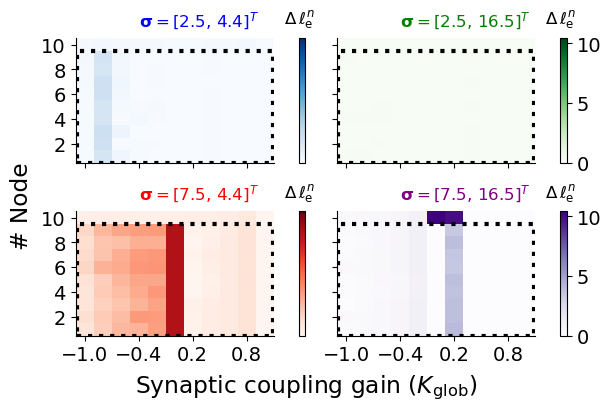

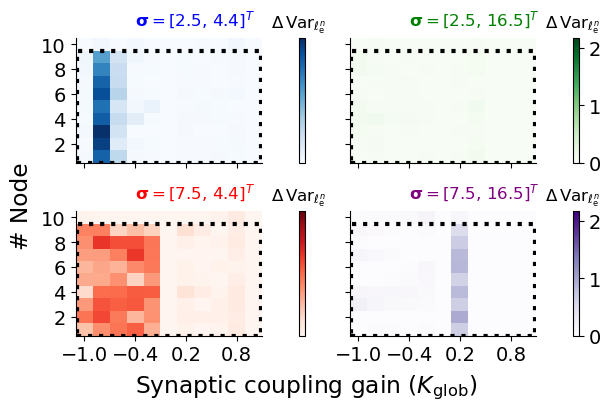

In [21]:
Ylabel=r"Synaptic coupling gain $(K_\mathrm{glob})$"

for var in modLyapB_mean.keys():
    fullLyapMeanB = np.zeros((nNodes, 4, len(Karr)))
    fullLyapVarB = np.zeros((nNodes, 4, len(Karr)))

    fullLyapMeanB[0, :, :] = abs(modLyapB_mean[var] - modLyapRB_mean)
    fullLyapMeanB[1:, :, :] = abs(nonmodLyapB_mean[var] - nonmodLyapRB_mean)

    fullLyapVarB[0, :, :] = abs(modLyapB_var[var] - modLyapRB_var)
    fullLyapVarB[1:, :, :] = abs(nonmodLyapB_var[var] - nonmodLyapRB_var)
    
    meanvarplot(fullLyapMeanB, figsize=(6,4), M=0, Xarr=Karr, Ylabel=Ylabel, offset=1.5, variable = r"$\Delta\,\ell_{\rm e}^n$",
                    figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_LyapMean.jpg")
    meanvarplot(fullLyapVarB, figsize=(6,4), M=0,  Xarr=Karr, Ylabel=Ylabel, offset=0.25, variable = r"$\Delta\,\mathrm{Var}_{\ell_{\rm e}^n}$",
                    figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_LyapVar.jpg")

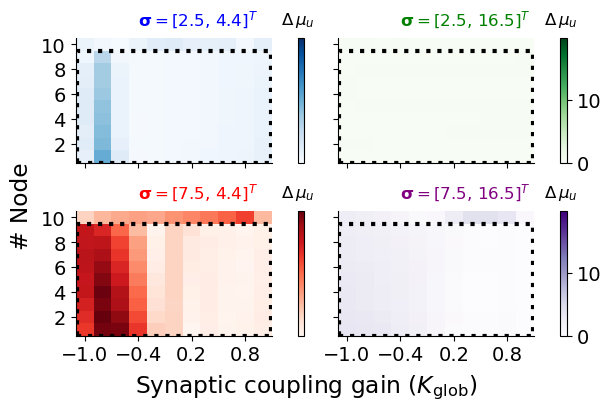

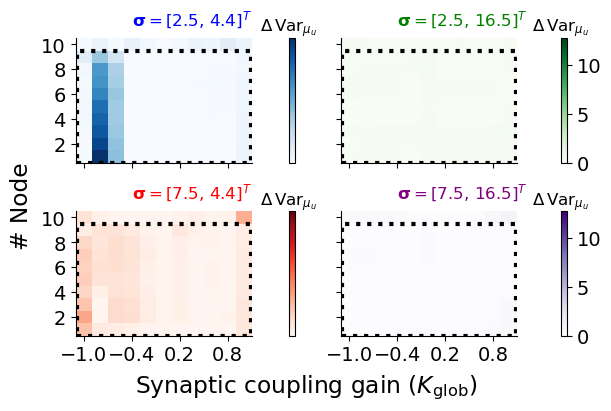

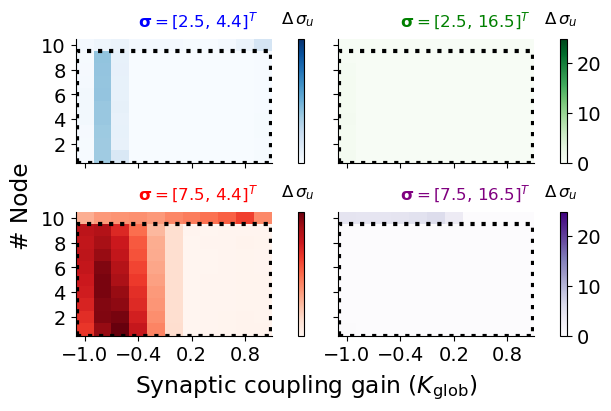

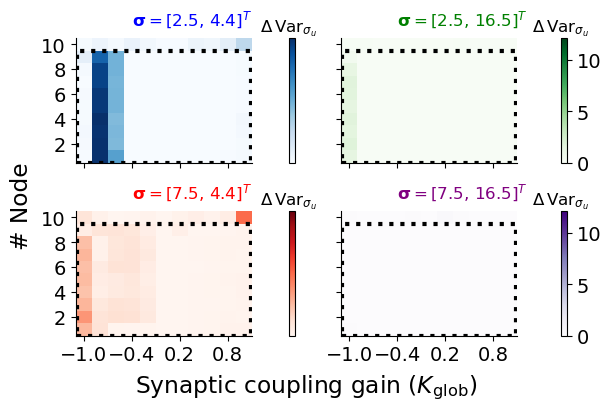

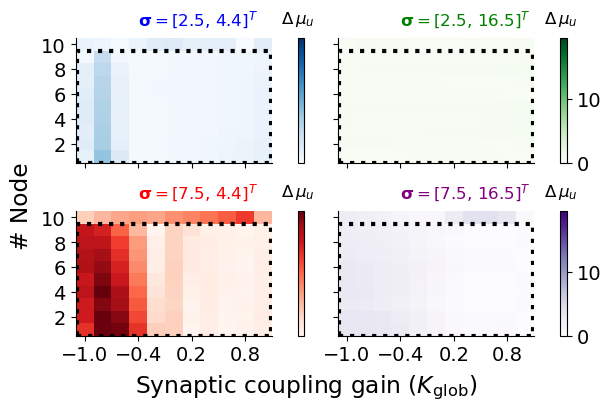

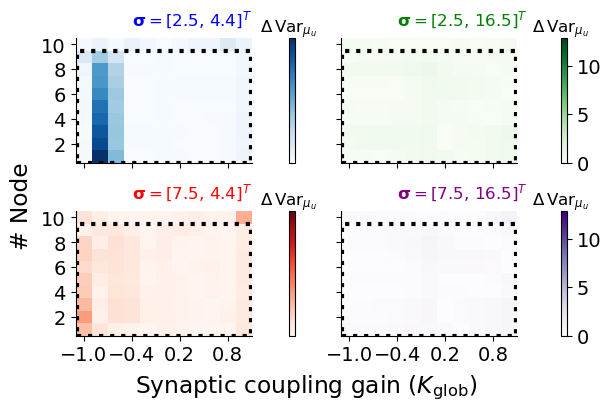

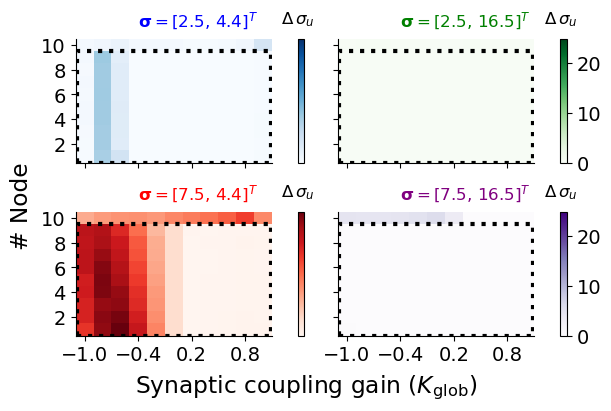

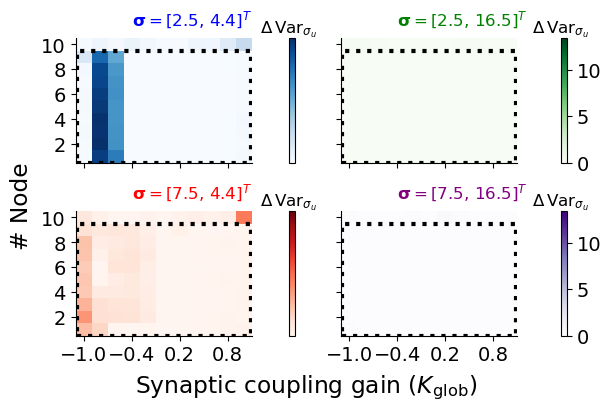

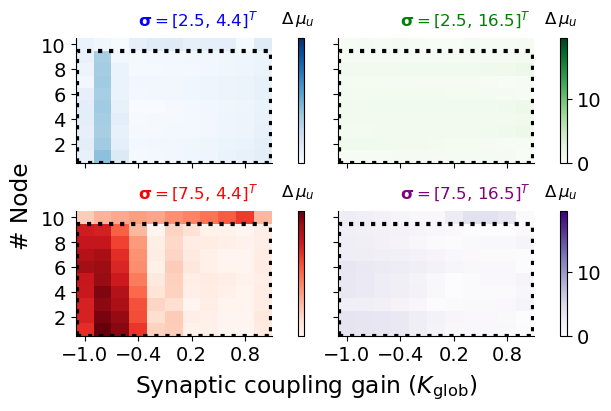

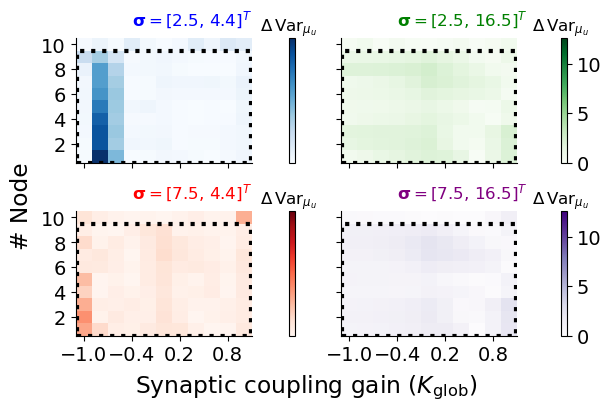

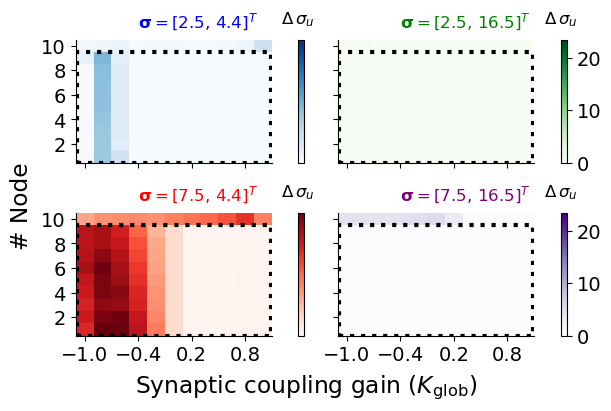

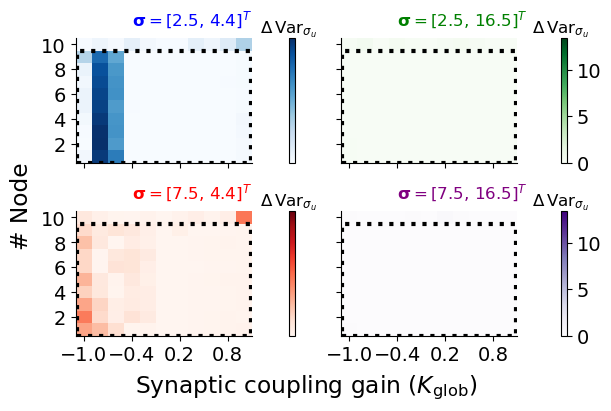

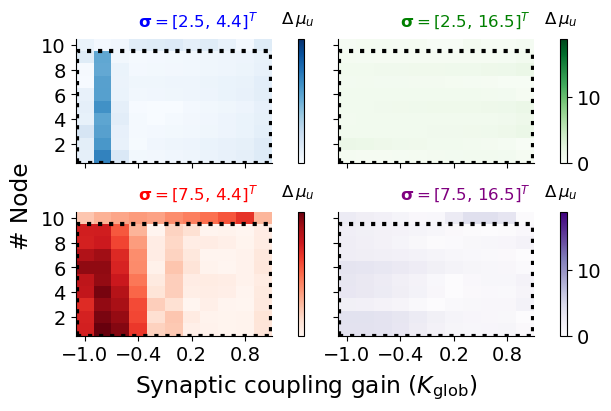

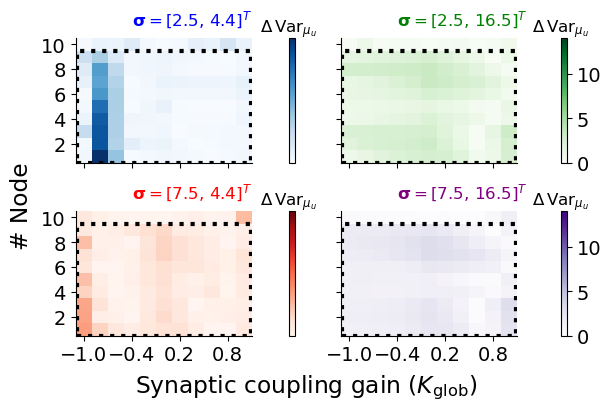

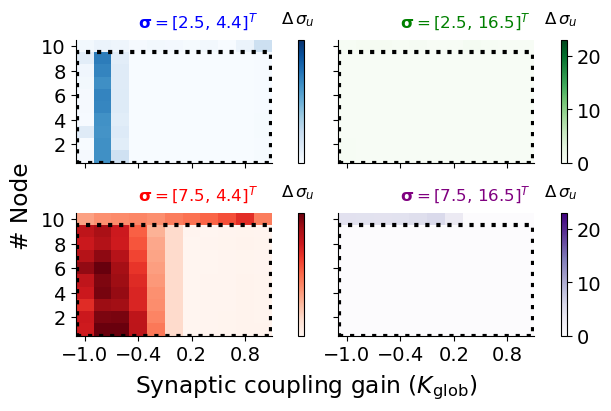

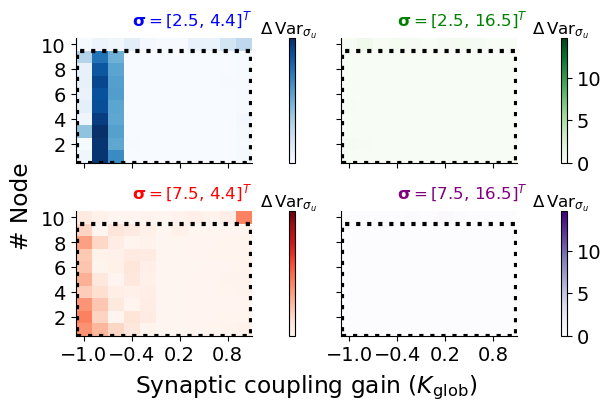

In [22]:
Ylabel=r"Synaptic coupling gain $(K_\mathrm{glob})$"

for var in modLyapB_mean.keys():
    meanvarplot(abs(MeanMeanB[var] - MeanMeanRB), M =0,  figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=3, variable = r"$\Delta\,\mu_u$",
                    figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_MeanNeural.jpg")
    meanvarplot(abs(VarMeanB[var] - VarMeanRB), M =0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1, variable = r"$\Delta\,\mathrm{Var}_{\mu_u}$",
                    figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_VarMeanNeural.jpg")
    meanvarplot(abs(MeanVarB[var] - MeanVarRB), M =0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=4, variable = r"$\Delta\,\sigma_u$",
                    figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_VarNeural.jpg")
    meanvarplot(abs(VarVarB[var] - VarVarRB), M =0, figsize=(6,4), Xarr=Karr, Ylabel=Ylabel, offset=1, variable = r"$\Delta\,\mathrm{Var}_{\sigma_u}$",
                    figroot=figurerootB, filename=f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_VarVarNeural.jpg")

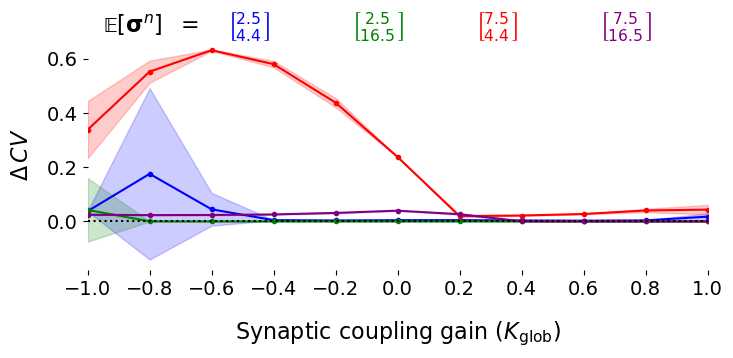

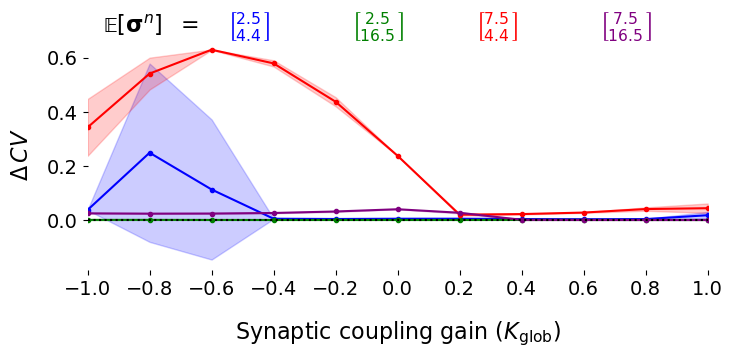

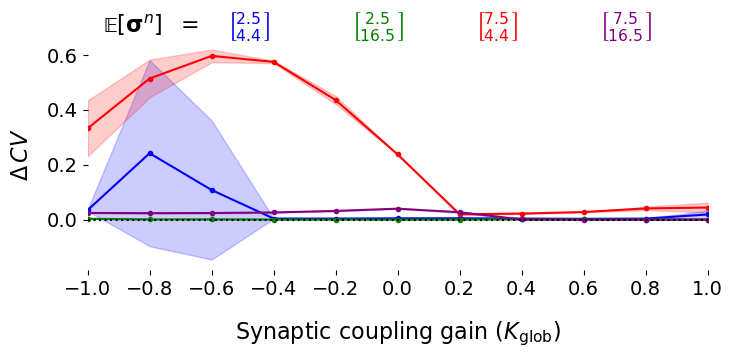

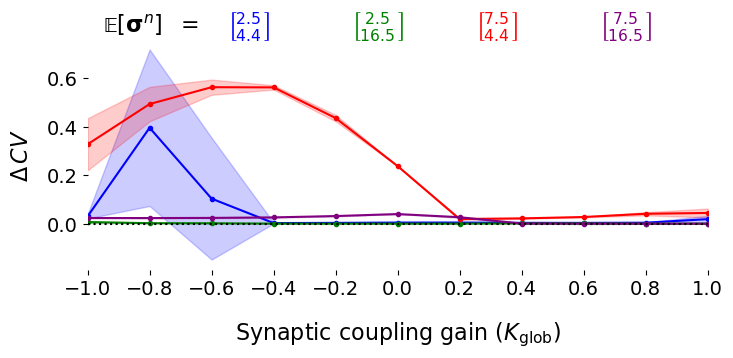

In [23]:
colors = ['b', 'g', 'r', 'purple']
for var in cvAMean.keys():
    plt.figure(figsize=(8, 3))
    dCVMean = abs(cvBMean[var] - cvRBMean)
    dCVVar = abs(cvBVar[var] - cvRBVar)

    for k in range(4):
        plt.plot(Karr, dCVMean[k, :], ".-", color=colors[k])
        plt.fill_between(Karr, dCVMean[k, :] - dCVVar[k, :], dCVMean[k, :] + dCVVar[k, :], color=colors[k], alpha=0.2)

    plt.axhline(y=0, color = 'k', linestyle=':')
    plt.ylabel(r"$\Delta\,CV$", fontsize=16, labelpad=10)
    plt.xlabel(r"Synaptic coupling gain $(K_{\mathrm{glob}})$", fontsize=16, labelpad=15)
    plt.xlim(min(Karr), max(Karr))
    plt.xticks(Karr)
    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)

    plt.text(-0.95, np.max(dCVMean + dCVVar) * 1.1 , r'$\mathrm{\mathbb{E}}[\mathbf{\sigma}^n]~~= $', color = 'k',  fontsize=16)

    plt.text(-0.55, np.max(dCVMean + dCVVar) * 1.1, r'$\genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = colors[0],  fontsize=16)
    plt.text(-0.15, np.max(dCVMean + dCVVar) * 1.1, r'$\genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = colors[1],  fontsize=16)
    plt.text(0.25, np.max(dCVMean + dCVVar) * 1.1, r'$\genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = colors[2],  fontsize=16)
    plt.text(0.65, np.max(dCVMean + dCVVar) * 1.1, r'$\genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = colors[3],  fontsize=16)

    plt.savefig(os.path.join(figurerootB, f"Imod_{params['i_mod']:.3f}mV_rho_{var:.2f}_dCV.jpg"), dpi=300, bbox_inches='tight')
    plt.show()

rho = 0.10 | sigma_e [2.5        2.48164224 2.4901186  2.38129822 2.53500833 2.63153004
 2.58868696 2.34113308 2.52622366 2.5374774 ]
rho = 0.10 | sigma_i [4.4        4.35296066 4.25173095 4.43441549 4.47143994 4.26884514
 4.29142196 4.28288675 4.47490735 4.44013038]
rho = 1.00 | sigma_e [2.5        2.44194766 2.46875228 2.12463201 2.61070607 2.9159345
 2.78045279 1.99761868 2.5829265  2.61851395]
rho = 1.00 | sigma_i [4.4        4.25124855 3.93113211 4.50883134 4.62591293 3.98525192
 4.05664608 4.02965539 4.63687785 4.52690341]
rho = 2.00 | sigma_e [2.5        2.42978782 2.45580905 1.9691495  2.73730339 3.08822022
 2.89662014 1.78952552 2.61727578 2.66760404]
rho = 2.00 | sigma_i [4.4        4.18963368 3.73692067 4.55391076 4.71948913 3.81345764
 3.91442422 3.87625363 4.73499587 4.57946852]
rho = 0.10 | sigma_e [2.5        2.48164224 2.4901186  2.38129822 2.53500833 2.63153004
 2.58868696 2.34113308 2.52622366 2.5374774 ]
rho = 0.10 | sigma_i [16.5        16.45296066 16.35173095 16.53

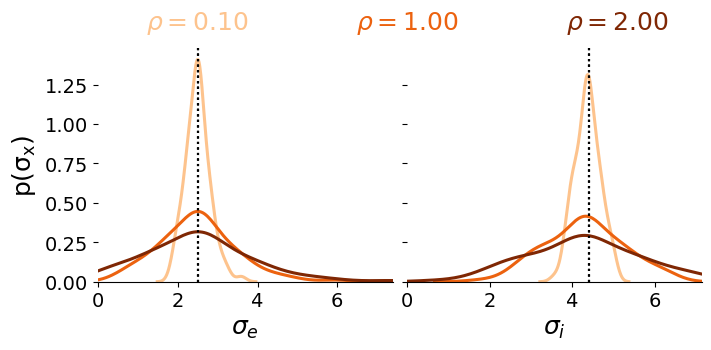

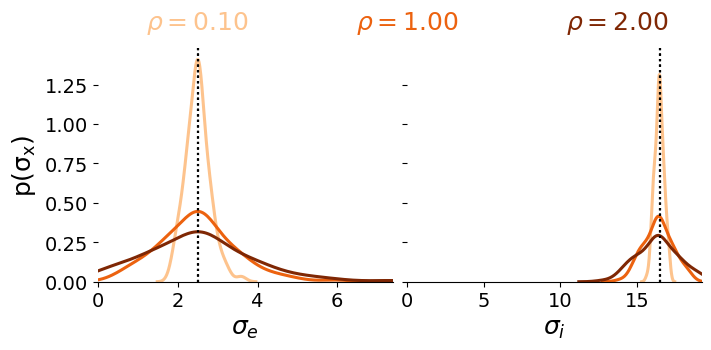

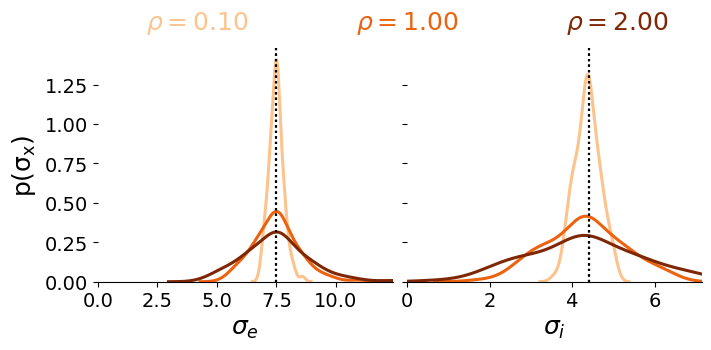

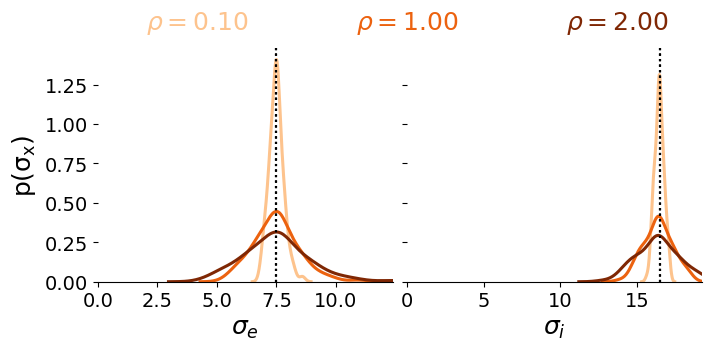

In [26]:
import seaborn as sns
sigeArr = [2.5, 7.5]
sigiArr = [4.4, 16.5]

rho = 2
sigCov = rho * np.eye(2)
colors = ["Blues", "Greens", "Reds", "Purples"]
k = 0

for nse, _sige in enumerate(sigeArr):
    for nsi, _sigi in enumerate(sigiArr):
        fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True, layout="constrained")
        _colors= plt.get_cmap("Oranges")
        colorIter = iter(_colors(np.linspace(0.3, 1, len(sigVar[1:]))))

        for nr, rho in enumerate(sigVar[1:]):
            color = next(colorIter)
            sigCov = rho * np.eye(2)
            # Creating sigma array with covariance
            sigma = np.zeros((nTrials, 2 * nNodes))

            sigMean = np.array([_sige, _sigi])
            for q in range(nTrials):
                np.random.seed(q * 10 + 5)
                sigmaNet = np.random.multivariate_normal(sigMean, sigCov, nNodes)
                sigmaNet[0, :] = sigMean

                sigma[q, :] = abs(sigmaNet.flatten())
            
            sige_ = sigma[:, ::2]
            sige_ = sige_.flatten()
            print(f"rho = {rho:.2f} | sigma_e", np.mean(sigma[:, ::2], axis=0))
            print(f"rho = {rho:.2f} | sigma_i", np.mean(sigma[:, 1::2], axis=0))


            sigi_ = sigma[:, 1::2]
            sigi_ = sigi_.flatten()

            sns.kdeplot(data=sige_, color=color, linewidth=2.2,  ax=axes[0])
            sns.kdeplot(data=sigi_, color=color, linewidth=2.2,  ax=axes[1])
            axes[0].set_xlim(0, np.max(sige_))
            axes[1].set_xlim(0, np.max(sigi_))
            axes[0].axvline(x=_sige, color="k", linestyle=":")
            axes[1].axvline(x=_sigi, color="k", linestyle=":")
            
            fig.text(0.2 + nr * .3, 1.05, r"$\rho = $"+f"{rho:.2f}", color=color, fontsize=18)
        axes[0].set_ylabel(r"$\rm p(\sigma_x)$", labelpad=5, fontsize=18)
        axes[0].set_xlabel(r"$\sigma_e$", fontsize=18)
        axes[1].set_xlabel(r"$\sigma_i$", fontsize=18)

        for pos in ["right", "top", "left"]:
            axes[0].spines[pos].set_visible(False) 
            axes[1].spines[pos].set_visible(False)

        
        k += 1
